## Importing Required Libraries

In [1]:
import os
import pickle
import catboost as cb
from time import time
import shap
import optuna
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import lightgbm as lgb
from sklearn.ensemble import AdaBoostRegressor
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import GradientBoostingRegressor

c:\Users\USER\anaconda3\lib\site-packages\xgboost\compat.py:85: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index


## Importing Dataset

In [2]:
data = pd.read_excel(r"Ea prediction dataset 302 reactionswithfnp.xlsx")
data = data.dropna()

In [3]:
x=data.iloc[:,7:]
y=data[["Ea"]]

## Feature Engineering

In [5]:
model=cb.CatBoostRegressor(random_state=42,verbose=False)
model.fit(x,y)
preds=model.predict(x)
r2=r2_score(y,preds)
mae=mean_absolute_error(y,preds)

print('MAE = ', mae)
print('R^2 = ', r2)

MAE =  0.049372745804436756
R^2 =  0.9770210591790702


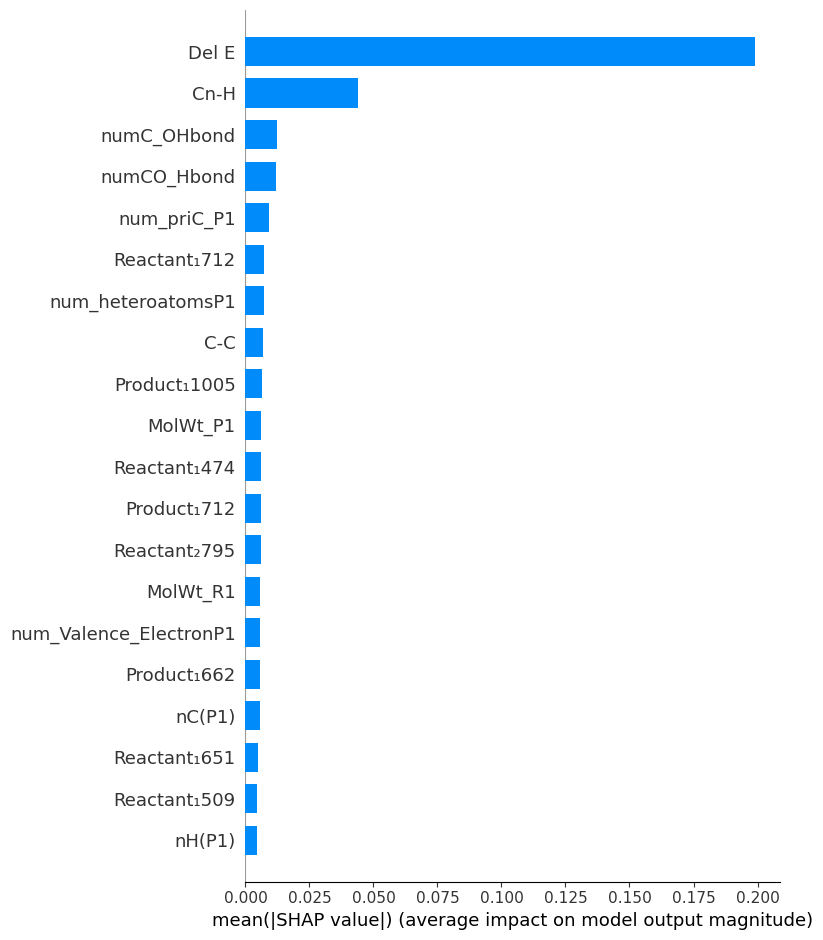

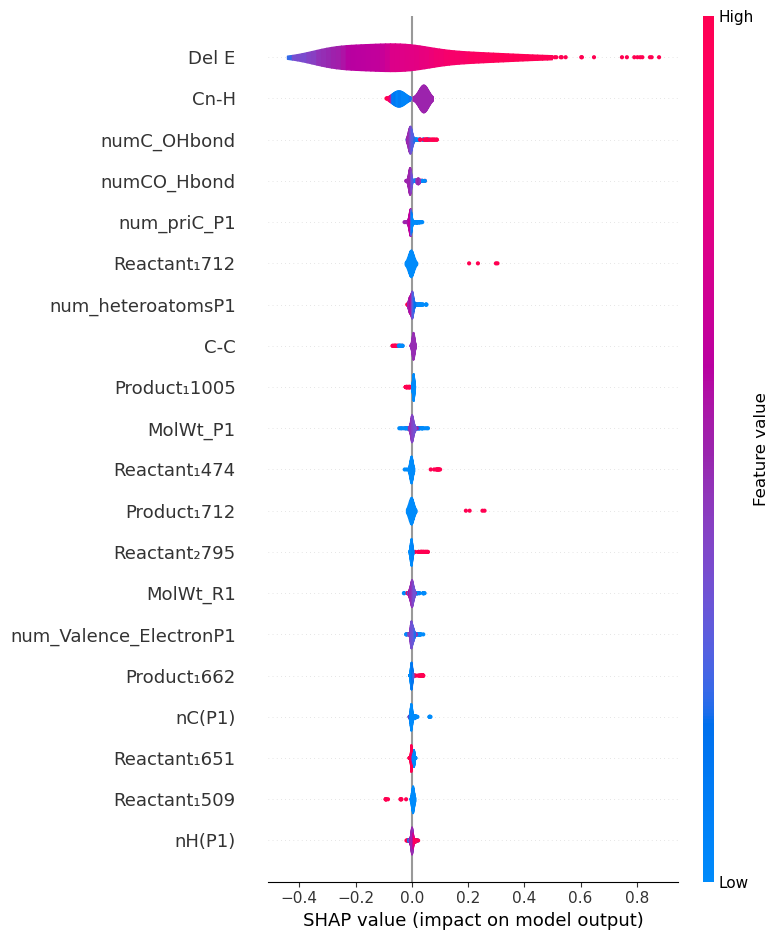

In [14]:
explainer = shap.Explainer(model)
shap_values = explainer(x)
shap.summary_plot(shap_values, features=x,feature_names=x.columns ,plot_type='bar')
shap.summary_plot(shap_values, features=x, feature_names=x.columns,plot_type='violin')
#shap.plots.waterfall(shap_values[0], max_display=14)
#shap.plots.bar(shap_values)
#shap.plots.beeswarm(shap_values)
#shap.plots.heatmap(shap_values[:50])
#shap.plots.scatter(shap_values[:, "Del E"], color=shap_values)


## Droping Coorelated features

In [4]:
x_base=x.iloc[:,:46]
x_finger=x[['Reactant₁712','Reactant₂712','Product₁712','Product₂712','Reactant₁795','Reactant₂795','Product₁795','Product₂795','Reactant₁474','Reactant₂474','Product₁474','Product₂474','Reactant₁1005','Reactant₂1005','Product₁1005','Product₂1005',]]
cor = x_base.corr('pearson')
# get upper triangle of correlation matrix
upper = cor.where(np.triu(np.ones(cor.shape), k=1).astype(np.bool))

# find features with correlation greater than 0.90
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

# drop highly correlated features
x_base.drop(to_drop, axis=1, inplace=True)

x = pd.concat([x_base,x_finger], axis=1, join='inner')

## Without Hyperparamter Tuning

In [16]:
x_train, x_test,y_train, y_test=train_test_split(x,y,test_size=0.1,random_state=42)
df_simple_reg = pd.DataFrame(columns=['Model Name','Model Params','Fit Time','R2 Train','R2 Test','MAE Train','MAE Test'])
# Build a dictionary of model names
from collections import OrderedDict
simple_reg_model_names = OrderedDict({
    'rr': KernelRidge,
    'rfr': RandomForestRegressor,
    'svr': SVR,
    'knr': KNeighborsRegressor,
    'lgbm': lgb.LGBMRegressor,
    'ada': AdaBoostRegressor,
    "cat": CatBoostRegressor,
    'xgb': xgb.XGBRegressor,
    'gbr': GradientBoostingRegressor
    
})

def model_train_eval(model,X_train,Y_train,X_test,Y_test):
    #Fit the model
    t = time()
    model = model()
    model.fit(X_train,Y_train)
    time_to_fit = time()-t

    #Evaluate the model
    y_actual = Y_train
    y_predicted = model.predict(X_train)
    y_test_predicted = model.predict(X_test)

    #Get the scores
    r2_Score = r2_score(y_actual,y_predicted)
    r2_Score_test = r2_score(Y_test,y_test_predicted)
    mae = mean_absolute_error(y_actual,y_predicted)
    maetest = mean_absolute_error(Y_test,y_test_predicted)

    #Results
    result_dict = {
        'Model Name': type(model).__name__,
        'Model Params': model.get_params(),
        'Fit Time': time_to_fit,
        'R2 Train': r2_Score,
        'R2 Test': r2_Score_test,
        'MAE Train': mae,
        'MAE Test': maetest}
    return result_dict

simple_reg_models = OrderedDict()
# Loop through each model type, fit and predict, and evaluate and store results
for model_name, model in simple_reg_model_names.items():
    print(f'Currently running {model_name}: {model.__name__}')
    result_dict = model_train_eval(model,x_train, y_train,x_test, y_test)
    df_simple_reg = df_simple_reg.append(result_dict, ignore_index=True)

## Get the best fit model based on r2score
df_simple_reg = df_simple_reg.sort_values('MAE Test', ignore_index=True)
df_simple_reg    

Currently running rr: KernelRidge
Currently running rfr: RandomForestRegressor
Currently running svr: SVR
Currently running knr: KNeighborsRegressor
Currently running lgbm: LGBMRegressor
Currently running ada: AdaBoostRegressor
Currently running cat: CatBoostRegressor
Learning rate set to 0.033311
0:	learn: 0.3921511	total: 510us	remaining: 510ms
1:	learn: 0.3873468	total: 1.2ms	remaining: 600ms
2:	learn: 0.3826841	total: 1.85ms	remaining: 615ms
3:	learn: 0.3785272	total: 2.5ms	remaining: 624ms
4:	learn: 0.3741307	total: 3.17ms	remaining: 631ms
5:	learn: 0.3702077	total: 3.86ms	remaining: 640ms
6:	learn: 0.3657487	total: 4.53ms	remaining: 642ms
7:	learn: 0.3623523	total: 5.2ms	remaining: 644ms
8:	learn: 0.3587850	total: 5.86ms	remaining: 645ms
9:	learn: 0.3552018	total: 6.48ms	remaining: 641ms
10:	learn: 0.3518867	total: 7.22ms	remaining: 649ms
11:	learn: 0.3483493	total: 7.94ms	remaining: 654ms
12:	learn: 0.3454913	total: 8.59ms	remaining: 652ms
13:	learn: 0.3423152	total: 9.33ms	rema

,Model Name,Model Params,Fit Time,R2 Train,R2 Test,MAE Train,MAE Test
0,GradientBoostingRegressor,"{'alpha': 0.9, 'ccp_alpha': 0.0, 'criterion': ...",0.078584,0.886660,0.711996,0.104669,0.153913
1,CatBoostRegressor,{'loss_function': 'RMSE'},1.617685,0.979820,0.674786,0.044129,0.179419
2,LGBMRegressor,"{'boosting_type': 'gbdt', 'class_weight': None...",0.045341,0.850121,0.596478,0.116784,0.184099
3,RandomForestRegressor,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri...",0.234754,0.939874,0.571446,0.074307,0.194890
4,AdaBoostRegressor,"{'base_estimator': None, 'learning_rate': 1.0,...",0.106723,0.654225,0.588136,0.193149,0.197992
5,KernelRidge,"{'alpha': 1, 'coef0': 1, 'degree': 3, 'gamma':...",0.034175,0.651329,0.511056,0.182442,0.217874
6,XGBRegressor,"{'objective': 'reg:squarederror', 'base_score'...",0.066027,0.999926,0.499963,0.002151,0.219726
7,KNeighborsRegressor,"{'algorithm': 'auto', 'leaf_size': 30, 'metric...",0.001951,0.434234,0.278626,0.229830,0.279097
8,SVR,"{'C': 1.0, 'cache_size': 200, 'coef0': 0.0, 'd...",0.006094,0.094478,0.121832,0.289881,0.296073


## Tuning Hyperparameters

In [17]:
models=[
    RandomForestRegressor(),
    KNeighborsRegressor(),
    SVR(),
    KernelRidge(),
    AdaBoostRegressor(),
    lgb.LGBMRegressor(),
    xgb.XGBRegressor(),
    cb.CatBoostRegressor(),
    GradientBoostingRegressor(),
]

In [18]:
def rf_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 600, step=50),
        "max_depth": trial.suggest_int("max_depth", 2, 50, step=5),
        "max_features": trial.suggest_categorical("max_features", ["auto", "sqrt", "log2"]),
        "criterion": trial.suggest_categorical("criterion", ["squared_error", "absolute_error"]),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10, step=1),
        "min_impurity_decrease": trial.suggest_categorical("min_impurity_decrease", [0.0, 0.05, 0.1]),        
    }
    model = RandomForestRegressor(**params, silent=True)
    model.fit(x_train, y_train)
    predictions = model.predict(x_test)
    mae = mean_absolute_error(y_test, predictions)
    return mae

def knr_objective(trial):
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 2, 10, step=1),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
    }
    model = KNeighborsRegressor(**params)
    model.fit(x_train, y_train)
    predictions = model.predict(x_test)
    mae = mean_absolute_error(y_test, predictions)
    return mae

def svr_objective(trial):
    params = {
        "kernel": trial.suggest_categorical("kernel", ["linear", "poly", "rbf", "sigmoid"]),
        "degree": trial.suggest_int("degree", 2, 5, step=1),
        "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
        "C": trial.suggest_float("C", 0.1, 10, step=0.1),
        "epsilon": trial.suggest_float("epsilon", 0.01, 0.2, step=0.01),
    }
    model = SVR(**params)
    model.fit(x_train, y_train)
    predictions = model.predict(x_test)
    mae = mean_absolute_error(y_test, predictions)
    return mae

def krr_objective(trial):
    params = {
        "alpha": trial.suggest_float("alpha", 0.0001, 1, step=0.0001),
        "kernel": trial.suggest_categorical("kernel", ["linear", "poly", "rbf", "laplacian"]),
        "degree": trial.suggest_int("degree", 2, 5, step=1),
        "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
    }
    model = KernelRidge(**params)
    model.fit(x_train, y_train)
    predictions = model.predict(x_test)
    mae = mean_absolute_error(y_test, predictions)
    return mae

def ada_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 600, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.0001, 1, step=0.0001),
        "loss": trial.suggest_categorical("loss", ["linear", "square", "exponential"]),
    }
    model = AdaBoostRegressor(**params, random_state=42)
    model.fit(x_train, y_train)
    predictions = model.predict(x_test)
    mae = mean_absolute_error(y_test, predictions)
    return mae

def lgbm_objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.0001, 1, step=0.0001),
        "boosting_type": trial.suggest_categorical("boosting_type", ["gbdt", "dart", "goss"]),
        "num_leaves": trial.suggest_int("num_leaves", 20, 320, step=100),
        "max_depth": trial.suggest_int("max_depth", 5, 505, step=100),
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000, step=200),
    }
    model = lgb.LGBMRegressor(**params, silent=True)
    model.fit(x_train, y_train)
    predictions = model.predict(x_test)
    mae = mean_absolute_error(y_test, predictions)
    return mae

def xgb_objective(trial):
    params = {
        "booster": trial.suggest_categorical("booster", ["gbtree", "gblinear", "dart"]),
        "eta": trial.suggest_float("eta", 0.0001, 1, step=0.0001),
        "gamma": trial.suggest_float("gamma", 0.00001, 0.1, step=0.00001),
        "max_depth": trial.suggest_int("max_depth", 5, 55, step=5),
        "tree_method": trial.suggest_categorical("tree_method", ["auto", "exact", "approx", "hist"]),
    }
    model = xgb.XGBRegressor(**params, silent=True)
    model.fit(x_train, y_train)
    predictions = model.predict(x_test)
    mae = mean_absolute_error(y_test, predictions)
    return mae

def cat_objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations",500,1000, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 1, step=0.001),
        "depth": trial.suggest_int("depth", 2, 10, step=2),
        "subsample": trial.suggest_float("subsample", 0.1, 1, step=0.1),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.1, 1, step=0.1),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 10, step=1),
    }

    model = cb.CatBoostRegressor(**params, silent=True)
    model.fit(x_train, y_train)
    predictions = model.predict(x_test)
    mae = mean_absolute_error(y_test, predictions)
    return mae

def gbr_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 600, step=50),
        "max_depth": trial.suggest_int("max_depth", 2, 50, step=5),
        "learning_rate": trial.suggest_float("learning_rate", 0.0001, 1, step=0.0001),
    }
    model = GradientBoostingRegressor(**params, random_state=42)
    model.fit(x_train, y_train)
    predictions = model.predict(x_test)
    mae = mean_absolute_error(y_test, predictions)
    return mae

In [253]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

In [23]:
start=time()
all_data=pd.DataFrame(columns=['model','model params','TEST R2','TEST MAE','TRAINR2',"TRAINMAE"])


# train_test split
x_train, x_test,y_train, y_test=train_test_split(x,y,test_size=0.1, random_state=42)
#create directory if not exists
if not os.path.exists('./new_models'):
    os.makedirs('./new_models')
    

for model_idx in range(9):

    model_path='./new_models/model_{}.sav'.format(model_idx)

    if os.path.exists(model_path):
        model=pickle.load(open(model_path,'rb'))
        print('Model is saved already')
    else:
        if model_idx==0:
            study = optuna.create_study(direction='minimize')
            study.optimize(rf_objective, n_trials=100)
            model=RandomForestRegressor(**study.best_params)
            
        elif model_idx==1:
            score='neg_mean_absolute_error'

            knn_random=RandomizedSearchCV(estimator=knn_base,n_iter=30, param_distributions=knn_grid,cv=5,
                                    verbose=4,scoring=score)

            knn_random.fit(x_train,y_train)

            best_parameters=knn_random.best_params_
            knn_random=KNeighborsRegressor(**knn_random.best_params_)

            model=knn_random

        elif model_idx==2:
            score='neg_mean_absolute_error'
            # svr_random=RandomizedSearchCV(estimator=svr_base,n_iter=30, param_distributions=svr_grid, cv=5, scoring=score, random_state=42,verbose=4,
            #                  n_jobs=6)             
            svr_random=RandomizedSearchCV(estimator=svr_base,n_iter=30, param_distributions=svr_grid,cv=5,scoring=score, return_train_score=True, verbose=4)

            svr_random.fit(x_train,y_train)

            best_parameters=svr_random.best_params_
            svr_random=SVR(**svr_random.best_params_)

            model=svr_random

        elif model_idx==3:
            score='neg_mean_absolute_error'
            krr_random=RandomizedSearchCV(estimator=krr_base,n_iter=30, param_distributions=krr_grid,scoring=score,cv=5,verbose=4, n_jobs=-1 )
        #                 krr_random=GridSearchCV(estimator=krr_base,param_grid=krr_grid,cv=5,scoring=score, return_train_score=True, verbose=4)

            krr_random.fit(x_train,y_train)

            best_parameters=krr_random.best_params_
            krr_random=KernelRidge(**krr_random.best_params_)

            model=krr_random

        elif model_idx==4:
            score='neg_mean_absolute_error'
            # adaboost_random=RandomizedSearchCV(estimator=adaboost_base,param_distributions=adaboost_grid,n_iter=50,cv=5,verbose=4,random_state=3)

            adaboost_random=RandomizedSearchCV(estimator=adaboost_base,n_iter=30, param_distributions=adaboost_grid,
                                         cv=5,scoring=score, return_train_score=True, verbose=4)
            adaboost_random.fit(x_train,y_train)

            best_parameters=adaboost_random.best_params_
            adaboost_random=AdaBoostRegressor(**adaboost_random.best_params_)
            model=adaboost_random
            
        elif model_idx==5:
            lgbm_random=RandomizedSearchCV(estimator=lgbm_base,n_iter=30, param_distributions=lgbm_grid,
                                         cv=5,scoring=score, verbose=4)
            
            lgbm_random.fit(x_train, y_train)
            best_parameters=lgbm_random.best_params_
            lgbm_random=lgb.LGBMRegressor(**lgbm_random.best_params_)
            model=lgbm_random
            
        elif model_idx==6:
            xgb_random=RandomizedSearchCV(estimator=xgb_base,n_iter=30, param_distributions=xgb_grid,
                                         cv=5,scoring=score, verbose=4)

            xgb_random.fit(x_train, y_train)
            best_parameters=xgb_random.best_params_
            xgb_random=xgb.XGBRegressor(**xgb_random.best_params_)
            model=xgb_random
            
        elif model_idx==7:
            score='r2'
            cb_random=RandomizedSearchCV(estimator=cb_base, n_iter=30, param_distributions=cb_grid,
                                  cv=5,scoring=score, return_train_score=True, verbose=0)
            cb_random.fit(x_train, y_train, verbose=False)
            best_parameters=cb_random.best_params_
            cb_random=cb.CatBoostRegressor(**cb_random.best_params_, verbose=False)
            model=cb_random
            
        elif model_idx==8:
            gp_random=RandomizedSearchCV(estimator=gb_base, n_iter=30, param_distributions=gb_grid,
                                  cv=5,scoring=score, return_train_score=True, verbose=2)
            gp_random.fit(x_train, y_train)
            best_parameters=gp_random.best_params_
            gp_random=GradientBoostingRegressor(**gp_random.best_params_)
            model=gp_random
            
    pickle.dump(model,open(model_path,'wb'))
    best_parameters = model.get_params()
    model.fit(x_train,y_train)
    ytrain_pred=model.predict(x_train)
    y_pred=model.predict(x_test)

    all_data.loc[len(all_data)]=[str(model).split('(')[0],best_parameters,r2_score(y_test,y_pred),
    mean_absolute_error(y_pred,y_test),r2_score(y_train,ytrain_pred),mean_absolute_error(ytrain_pred,y_train)]

    all_data.to_csv('./new_models/result.csv')

end=time()
print('total_time_taken={}'.format(end-start))

Model is saved already
Model is saved already
Model is saved already
Model is saved already
Model is saved already
Model is saved already
Model is saved already
Model is saved already
Model is saved already
total_time_taken=1.8878164291381836


In [6]:
all_data=pd.read_csv('./new_models/result.csv')
all_data

,Unnamed: 0,model,model params,TEST R2,TEST MAE,TRAINR2,TRAINMAE
0,0,RandomForestRegressor,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri...",0.590453,0.186956,0.931435,0.081702
1,1,KNeighborsRegressor,"{'algorithm': 'auto', 'leaf_size': 30, 'metric...",0.301263,0.273387,0.374618,0.241119
2,2,SVR,"{'C': 0.1, 'cache_size': 200, 'coef0': 0.0, 'd...",0.668870,0.196281,0.663218,0.176871
3,3,KernelRidge,"{'alpha': 0.027, 'coef0': 1, 'degree': 2, 'gam...",0.697146,0.171844,0.828048,0.128109
4,4,AdaBoostRegressor,"{'base_estimator': None, 'learning_rate': 0.83...",0.667573,0.167495,0.670059,0.186145
5,5,LGBMRegressor,"{'boosting_type': 'goss', 'class_weight': None...",0.657208,0.169771,0.593601,0.196000
6,6,XGBRegressor,"{'objective': 'reg:squarederror', 'base_score'...",0.662853,0.157547,0.932068,0.079685
7,7,<catboost.core.CatBoostRegressor object at 0x0...,"{'iterations': 900, 'learning_rate': 0.083, 'd...",0.820500,0.132467,0.909434,0.092905
8,8,GradientBoostingRegressor,"{'alpha': 0.9, 'ccp_alpha': 0.0, 'criterion': ...",0.802957,0.137107,0.940283,0.073473


## SAVING TRAINED MODEL

In [28]:
cat=cb.CatBoostRegressor(**{'iterations': 900,
 'learning_rate': 0.083,
 'depth': 2,
 'loss_function': 'RMSE',
 'silent': True,
 'subsample': 1.0,
 'colsample_bylevel': 0.9,
 'min_data_in_leaf': 9})
cat.fit(x_train,y_train)
preds=cat.predict(x_test)
pickle.dump(cat, open('Ea.pkl','wb'))

## Predicting on unknown data

In [6]:
modelEa=pickle.load(open(r"Ea.pkl",'rb'))

In [7]:
data_predict=pd.read_csv(r"C:\Users\USER\Downloads\9237 Ea predict datasetwithfnp.csv")
data_predict

,Unnamed: 0,reaction,Del E,Reactant 1,Reactant 2,Product 1,Product 2,Is the reaction elementary,nC(R1),nC(R2),...,Reactant₂1015,Reactant₂1016,Reactant₂1017,Reactant₂1018,Reactant₂1019,Reactant₂1020,Reactant₂1021,Reactant₂1022,Reactant₂1023,Reactant₂1024
0,0,CH3CHCHCH2OH* + O* = CH3CHCHCH2O* + OH*,-0.765991,C/C=C/CO,[O],C/C=C/C[O],[OH],True,4,0,...,0,0,0,0,0,0,0,0,0,0
1,1,CH3CH2CHCH2OH* = CH3CH2CH2CH2O*,-0.296733,CC[CH]CO,*,CCCC[O],*,True,4,0,...,0,0,0,0,0,0,0,0,0,0
2,2,CH3CHCH2CHO* + CH3CHCHCH2OH* = CH3CHCH2CH2OH* ...,-0.332396,C/C=C/CO,C[CH]CC=O,C/C=C/C=O,C[CH]CCO,True,4,4,...,0,0,0,0,0,0,0,0,0,0
3,3,CH3CH2CHCH2OH* + CH3CHCH2CHO* = CH3CH2CH2CH2OH...,-1.311703,CC[CH]CO,C[CH]CC=O,CCCCO,C/C=C/C=O,True,4,4,...,0,0,0,0,0,0,0,0,0,0
4,4,CH3CH2CH2CH2O* + CH3CHCH2CHO* = CH3CH2CH2CH2OH...,-1.014970,CCCC[O],C[CH]CC=O,CCCCO,C/C=C/C=O,True,4,4,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9232,9232,HCOOH*+HCOOH* = COOH* + CHOHOH*,2.455708,O=CO,O=CO,[CH](O)O,[O][C](O),True,1,1,...,0,0,0,0,0,0,0,0,0,0
9233,9233,CH3CO*+CH3CO* = CH2CO* + CH3CHO*,0.512714,C[C][O],C[C][O],CC=O,C=C=O,True,2,2,...,0,0,0,0,0,0,0,0,0,0
9234,9234,CHO*+CHO* = CH* + HCOO*,-1.159056,[CH]=O,[CH]=O,C(=O)[O],[CH],True,1,1,...,0,0,0,0,0,0,0,0,0,0
9235,9235,CHCH2O*+CHCH2O* = CH2CH* + CHOCH2O*,-0.999892,[O]C[CH],[O]C[CH],[O]C[CH][O],[CH2][CH],True,2,2,...,0,0,0,0,0,0,0,0,0,0


In [8]:
data_153=data_predict[['Del E', 'nC(R1)', 'nC(R2)', 'nC(P2)', 'nO(R1)', 'nO(R2)', 'nO(P1)',
       'nO(P2)', 'nH(R1)', 'nH(R2)', 'nH(P2)', 'Cn-H', 'C-O', 'C-C',
       'numCO_Hbond', 'numC_OHbond', 'MolWt_R1', 'MolWt_P1', 'num_terC_R1',
       'num_terC_R2', 'num_terC_P1', 'num_terC_P2', 'num_secC_R1',
       'num_secC_R2', 'num_secC_P1', 'num_secC_P2', 'num_priC_R1',
       'num_priC_R2', 'num_priC_P1', 'num_priC_P2','Reactant₁712','Reactant₂712','Product₁712','Product₂712','Reactant₁795','Reactant₂795','Product₁795','Product₂795','Reactant₁474','Reactant₂474','Product₁474','Product₂474','Reactant₁1005','Reactant₂1005','Product₁1005','Product₂1005',]]
data_153

,Del E,nC(R1),nC(R2),nC(P2),nO(R1),nO(R2),nO(P1),nO(P2),nH(R1),nH(R2),...,Product₁795,Product₂795,Reactant₁474,Reactant₂474,Product₁474,Product₂474,Reactant₁1005,Reactant₂1005,Product₁1005,Product₂1005
0,-0.765991,4,0,0,1,1,1,1,8,0,...,0,1,0,0,0,0,0,0,0,0
1,-0.296733,4,0,0,1,0,1,0,9,0,...,1,0,0,0,0,0,0,0,0,0
2,-0.332396,4,4,4,1,1,1,1,8,7,...,0,0,0,0,0,1,0,1,1,0
3,-1.311703,4,4,4,1,1,1,1,9,7,...,1,0,0,0,1,0,0,1,0,1
4,-1.014970,4,4,4,1,1,1,1,9,7,...,1,0,0,0,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9232,2.455708,1,1,1,2,2,2,2,2,2,...,0,0,0,0,0,0,1,1,0,0
9233,0.512714,2,2,2,1,1,1,1,3,3,...,0,0,0,0,0,0,0,0,1,0
9234,-1.159056,1,1,1,1,1,2,0,1,1,...,0,0,0,0,0,0,0,0,1,0
9235,-0.999892,2,2,2,1,1,2,0,3,3,...,0,0,0,0,0,0,0,0,0,0


In [9]:
Ea=modelEa.predict(data_153)
Ea_df=pd.DataFrame()
Ea_df["Ea"]=Ea

In [11]:
predictedEawithreaction=pd.concat([data_predict[['reaction', 'Del E', 'Reactant 1', 'Reactant 2',
       'Product 1', 'Product 2','nC(R1)', 'nC(R2)', 'nC(P2)', 'nO(R1)', 'nO(R2)', 'nO(P1)',
       'nO(P2)', 'nH(R1)', 'nH(R2)', 'nH(P2)', 'Cn-H', 'C-O', 'C-C',
       'numCO_Hbond', 'numC_OHbond', 'MolWt_R1', 'MolWt_P1', 'num_terC_R1',
       'num_terC_R2', 'num_terC_P1', 'num_terC_P2', 'num_secC_R1',
       'num_secC_R2', 'num_secC_P1', 'num_priC_R1', 'num_priC_R2',
       'num_priC_P1', 'num_priC_P2']],Ea_df],axis=1, join='inner')

In [12]:
predictedEawithreaction.to_csv("predicted9k_1Dec.csv")

## Plotting

In [8]:
model=pickle.load(open(r"Ea.pkl",'rb'))

In [9]:
model.fit(x_train,y_train)
preds=model.predict(x_test)
train_pred=model.predict(x_train)
train_r2=r2_score(y_train,train_pred)
test_r2=r2_score(y_test,preds)

train_mae=mean_absolute_error(y_train,train_pred)
test_mae=mean_absolute_error(y_test,preds)

print('Train MAE = ', train_mae)
print('Train R^2 = ', train_r2)
print('Test MAE  = ', test_mae)
print('Test R^2  = ', test_r2)

Train MAE =  0.09290547376724881
Train R^2 =  0.9094341190112893
Test MAE  =  0.13246666841548
Test R^2  =  0.8205003994493284


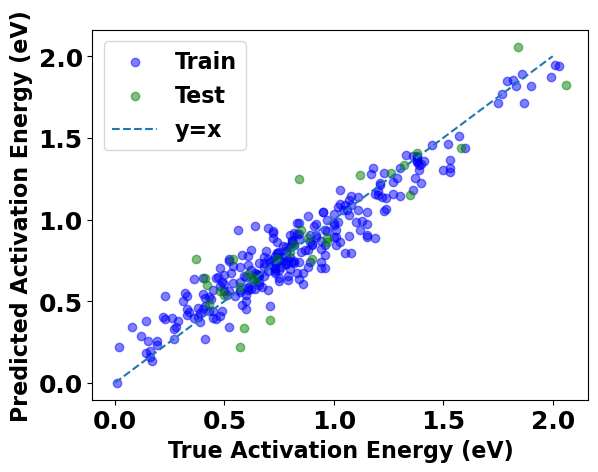

In [70]:
# Parity Plot
plt.scatter(y_train,train_pred,c="blue",alpha=0.5)
plt.scatter(y_test,preds,c="green",alpha=0.5)
plt.xlabel('True Activation Energy (eV)',fontsize=16,fontweight='bold')
plt.ylabel('Predicted Activation Energy (eV)',fontsize=16,fontweight='bold')
parity_x = np.linspace(0,2,100)
plt.plot(parity_x,parity_x,'--')
plt.xticks(fontweight='bold',fontsize= '18')
plt.yticks(fontweight='bold',fontsize= '18')
plt.legend(["Train","Test","y=x"],prop={'size': 16,'weight':'bold'})
#legend_properties = {'weight':'bold','size': 30}
#leg=plt.legend(prop=legend_properties)
#leg.get_frame().set_edgecolor('black')
#leg.get_frame().set_linewidth(2.0)
# #write r2 inside figure
# plt.text(1.5,0.8, 'Train $R^2$ :0.909 \n'
#          'Test $R^2$  :0.821', fontsize = 12,bbox = dict(facecolor = 'green', alpha = 0.5)) 
plt.savefig('Parity Ea.png',dpi=300)
plt.show()